In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, recall_score, precision_score, roc_auc_score)

plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path("/workspaces/industrial-ai-predictive-maintenance/data/raw/SKAB/data")

dfs = []
for folder in ["valve1", "valve2", "other"]:
    for f in sorted((DATA_PATH / folder).glob("*.csv")):
        df = pd.read_csv(f, sep=";", index_col="datetime", parse_dates=True)
        df["source"] = folder
        dfs.append(df)

df_all = pd.concat(dfs, join="outer").sort_index()
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

df_all[sensor_cols] = df_all[sensor_cols].fillna(df_all[sensor_cols].median())

print(f"Shape : {df_all.shape}")
print(f"Anomalies : {df_all['anomaly'].mean()*100:.1f}%")

Shape : (37401, 11)
Anomalies : 34.9%


In [2]:
# On ajoute des features de variance — clé d'après notre analyse delta_%
window = 30  # 30 secondes de fenêtre glissante

df_feat = df_all[sensor_cols].copy()

# Rolling stats sur les capteurs les plus discriminants
for col in ['Accelerometer1RMS', 'Accelerometer2RMS', 'Volume Flow RateRMS']:
    df_feat[f'{col}_rollstd']  = df_all[col].rolling(window).std()
    df_feat[f'{col}_rollmean'] = df_all[col].rolling(window).mean()

# Ratio vibration / débit — indicateur physique de cavitation
df_feat['vib_flow_ratio'] = (
    (df_all['Accelerometer1RMS'] + df_all['Accelerometer2RMS']) /
    (df_all['Volume Flow RateRMS'] + 1e-6)
)

df_feat = df_feat.dropna()
labels  = df_all.loc[df_feat.index, 'anomaly'].astype(int)

print(f"Features shape : {df_feat.shape}")
print(f"Features : {df_feat.columns.tolist()}")
print(f"Anomalies après dropna : {labels.mean()*100:.1f}%")

Features shape : (37372, 15)
Features : ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'Accelerometer1RMS_rollstd', 'Accelerometer1RMS_rollmean', 'Accelerometer2RMS_rollstd', 'Accelerometer2RMS_rollmean', 'Volume Flow RateRMS_rollstd', 'Volume Flow RateRMS_rollmean', 'vib_flow_ratio']
Anomalies après dropna : 34.3%


In [5]:
# Repartir de df_all propre avec reset_index pour éviter les doublons
df_work = df_all[sensor_cols + ['anomaly']].copy()
df_work = df_work.reset_index(drop=True)  # index numérique simple

# Rolling stats sur capteurs discriminants
window = 30
for col in ['Accelerometer1RMS', 'Accelerometer2RMS', 'Volume Flow RateRMS']:
    df_work[f'{col}_rollstd']  = df_work[col].rolling(window).std()
    df_work[f'{col}_rollmean'] = df_work[col].rolling(window).mean()

# Ratio vibration / débit
df_work['vib_flow_ratio'] = (
    (df_work['Accelerometer1RMS'] + df_work['Accelerometer2RMS']) /
    (df_work['Volume Flow RateRMS'] + 1e-6)
)

# Supprimer les NaN issus du rolling
df_work = df_work.dropna().reset_index(drop=True)

feature_cols = [c for c in df_work.columns if c != 'anomaly']
X = df_work[feature_cols]
y = df_work['anomaly'].astype(int)

print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"Anomalies : {y.mean()*100:.1f}%")
print(f"Index aligné : {len(X) == len(y)}")

X shape  : (37372, 15)
y shape  : (37372,)
Anomalies : 35.0%
Index aligné : True


In [6]:
train_mask = (y == 0).values
X_train = X[train_mask]
X_all   = X

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled   = scaler.transform(X_all)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.35,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_scaled)

preds  = (iso.predict(X_all_scaled) == -1).astype(int)
scores = -iso.score_samples(X_all_scaled)

print("=== Résultats Isolation Forest ===\n")
print(classification_report(y, preds, target_names=["Normal", "Anomalie"]))
print(f"ROC-AUC  : {roc_auc_score(y, scores):.4f}")
print(f"Recall   : {recall_score(y, preds):.4f}")
print(f"F1-score : {f1_score(y, preds):.4f}")

=== Résultats Isolation Forest ===

              precision    recall  f1-score   support

      Normal       0.78      0.65      0.71     24305
    Anomalie       0.50      0.65      0.57     13067

    accuracy                           0.65     37372
   macro avg       0.64      0.65      0.64     37372
weighted avg       0.68      0.65      0.66     37372

ROC-AUC  : 0.7276
Recall   : 0.6549
F1-score : 0.5680


In [7]:
from sklearn.metrics import precision_recall_curve

precision_arr, recall_arr, thresholds = precision_recall_curve(y, scores)

# Trouver le seuil qui maximise F1
f1_arr = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-8)
best_idx = f1_arr.argmax()
best_threshold = thresholds[best_idx]

print(f"Seuil optimal    : {best_threshold:.4f}")
print(f"Precision        : {precision_arr[best_idx]:.4f}")
print(f"Recall           : {recall_arr[best_idx]:.4f}")
print(f"F1               : {f1_arr[best_idx]:.4f}")

# Appliquer le seuil optimal
preds_tuned = (scores >= best_threshold).astype(int)

print("\n=== Résultats après tuning du seuil ===\n")
print(classification_report(y, preds_tuned, target_names=["Normal", "Anomalie"]))
print(f"ROC-AUC  : {roc_auc_score(y, scores):.4f}")
print(f"Recall   : {recall_score(y, preds_tuned):.4f}")
print(f"F1-score : {f1_score(y, preds_tuned):.4f}")

Seuil optimal    : 0.4319
Precision        : 0.4710
Recall           : 0.8656
F1               : 0.6101

=== Résultats après tuning du seuil ===

              precision    recall  f1-score   support

      Normal       0.87      0.48      0.62     24305
    Anomalie       0.47      0.87      0.61     13067

    accuracy                           0.61     37372
   macro avg       0.67      0.67      0.61     37372
weighted avg       0.73      0.61      0.61     37372

ROC-AUC  : 0.7276
Recall   : 0.8656
F1-score : 0.6101


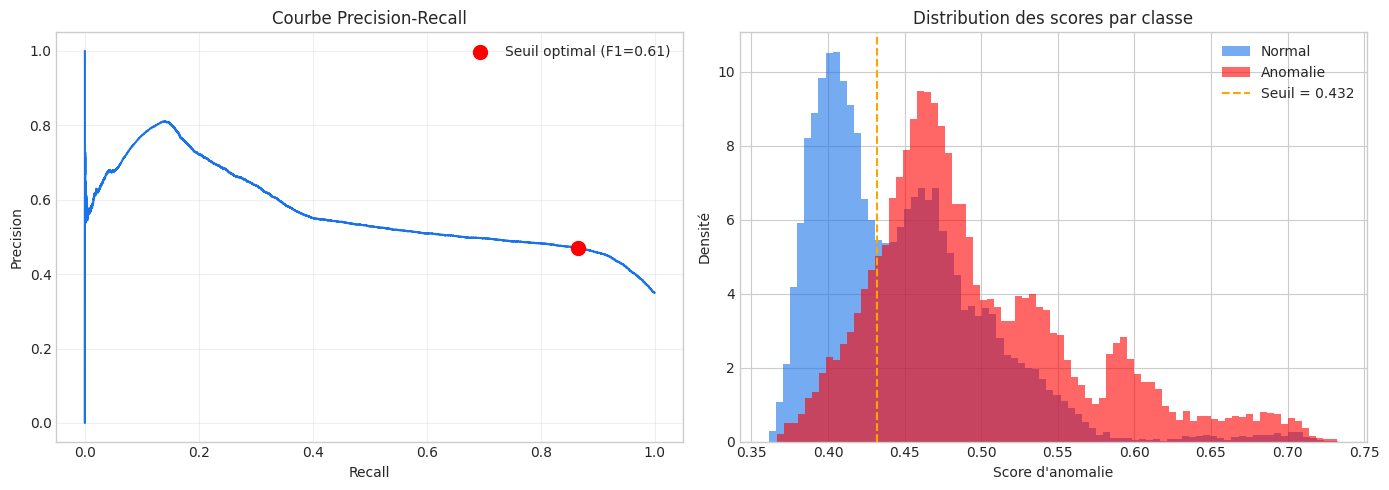

OK


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe PR
axes[0].plot(recall_arr, precision_arr, color='#1a73e8', linewidth=1.5)
axes[0].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', s=100, zorder=5, label=f'Seuil optimal (F1={f1_arr[best_idx]:.2f})')
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Courbe Precision-Recall")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Score d'anomalie — distribution normale vs anomalie
axes[1].hist(scores[y==0], bins=80, alpha=0.6, color='#1a73e8',
             label='Normal', density=True)
axes[1].hist(scores[y==1], bins=80, alpha=0.6, color='red',
             label='Anomalie', density=True)
axes[1].axvline(best_threshold, color='orange', linestyle='--',
                linewidth=1.5, label=f'Seuil = {best_threshold:.3f}')
axes[1].set_xlabel("Score d'anomalie")
axes[1].set_ylabel("Densité")
axes[1].set_title("Distribution des scores par classe")
axes[1].legend()

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/isolation_forest_tuned.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")

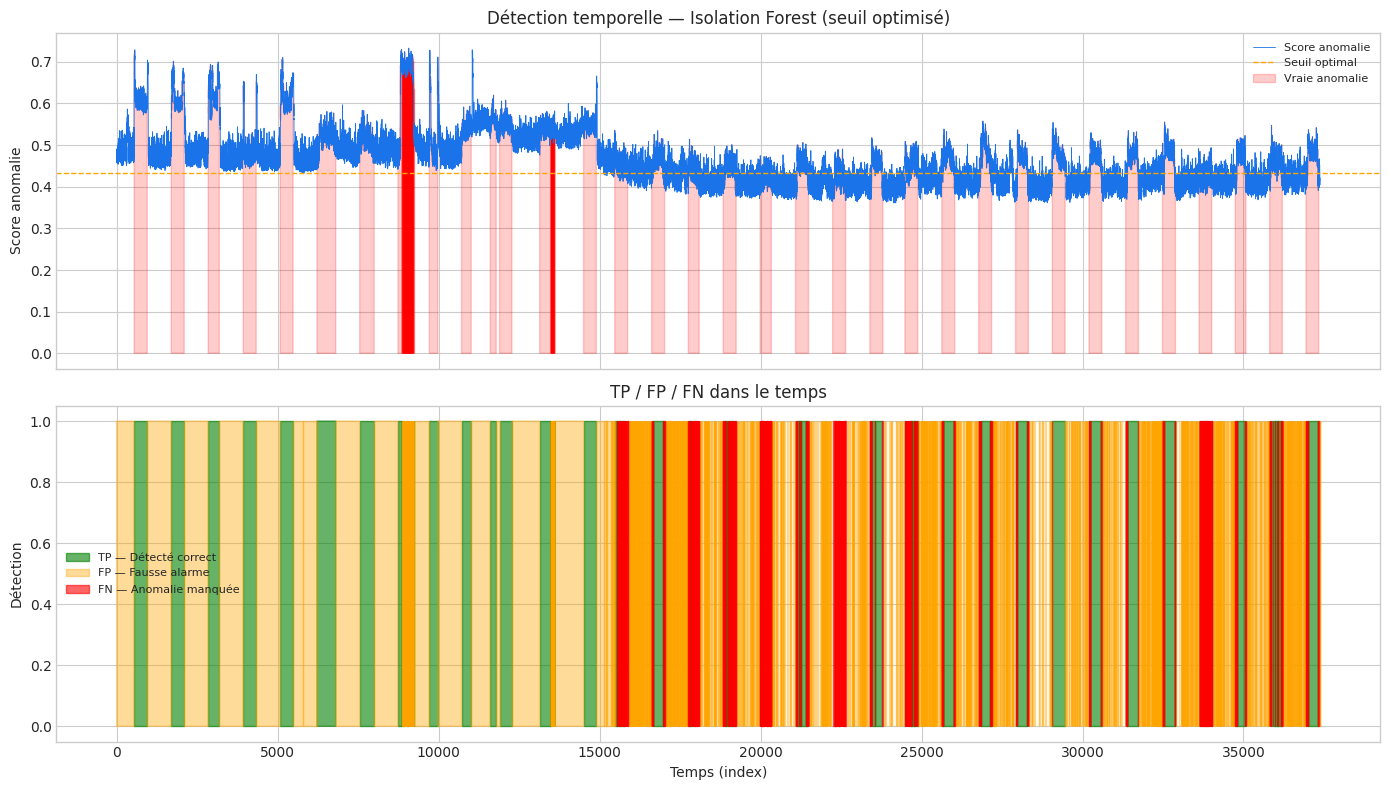

OK


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

idx = np.arange(len(y))

axes[0].plot(idx, scores, linewidth=0.6, color='#1a73e8', label='Score anomalie')
axes[0].axhline(best_threshold, color='orange', linestyle='--',
                linewidth=1, label=f'Seuil optimal')
axes[0].fill_between(idx, 0, scores,
                     where=y.values==1,
                     alpha=0.2, color='red', label='Vraie anomalie')
axes[0].set_ylabel("Score anomalie")
axes[0].legend(fontsize=8)
axes[0].set_title("Détection temporelle — Isolation Forest (seuil optimisé)")

# Visualiser les TP, FP, FN
tp = ((preds_tuned == 1) & (y == 1)).values
fp = ((preds_tuned == 1) & (y == 0)).values
fn = ((preds_tuned == 0) & (y == 1)).values

axes[1].fill_between(idx, 0, 1, where=tp, color='green',  alpha=0.6, label='TP — Détecté correct')
axes[1].fill_between(idx, 0, 1, where=fp, color='orange', alpha=0.4, label='FP — Fausse alarme')
axes[1].fill_between(idx, 0, 1, where=fn, color='red',    alpha=0.6, label='FN — Anomalie manquée')
axes[1].set_ylabel("Détection")
axes[1].set_xlabel("Temps (index)")
axes[1].legend(fontsize=8)
axes[1].set_title("TP / FP / FN dans le temps")

plt.tight_layout()
plt.savefig("/workspaces/industrial-ai-predictive-maintenance/notebooks/isolation_forest_detections.png",
            dpi=120, bbox_inches="tight")
plt.show()
print("OK")